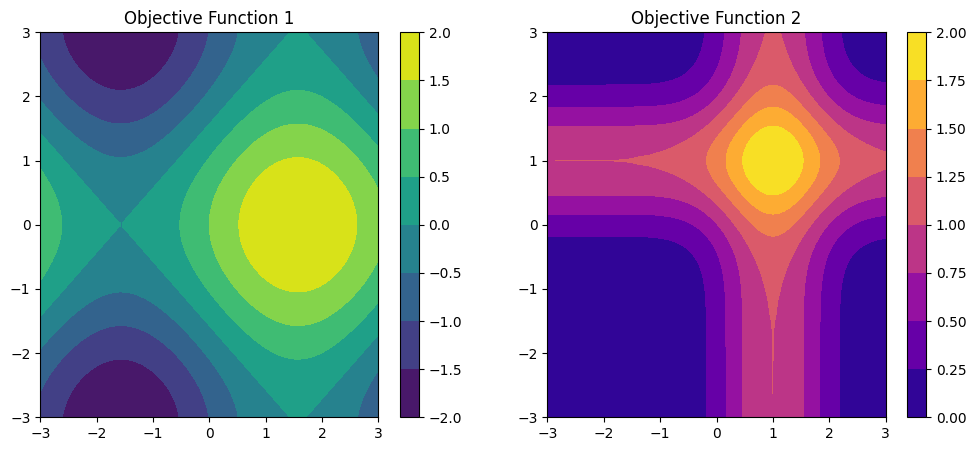

Optimal solution: [-1.57748357 -3.14120971]
Obj 1 value: -1.9999775671203084
Obj 2 value: 0.0013025984404122358


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class MultiObjectiveOptimizer:
    def __init__(self, objectives):
        self.objectives = objectives

    def optimize(self, x0, learning_rate=0.01, num_iterations=1000):
        x = np.array(x0, dtype=float)
        x_history = [x.copy()]
        for _ in range(num_iterations):
            gradients = self.compute_gradients(x)
            x -= learning_rate * gradients
            x_history.append(x.copy())
        return np.array(x_history)

    def compute_gradients(self, x):
        gradients = np.zeros_like(x)
        for obj in self.objectives:
            obj_gradient = obj.gradient(x)
            gradients += obj_gradient
        return gradients

class ObjectiveFunction:
    def __init__(self, function):
        self.function = function

    def evaluate(self, x):
        return self.function(x)

    def gradient(self, x, epsilon=1e-5):
        grad = np.zeros_like(x)
        for i in range(len(x)):
            x_plus = np.copy(x)
            x_plus[i] += epsilon
            x_minus = np.copy(x)
            x_minus[i] -= epsilon
            grad[i] = (self.function(x_plus) - self.function(x_minus)) / (2 * epsilon)
        return grad

# Objective Functions
def objective1(x):
    return np.sin(x[0]) + np.cos(x[1])

def objective2(x):
    return np.exp(-(x[0] - 1) ** 2) + np.exp(-(x[1] - 1) ** 2)

obj1 = ObjectiveFunction(objective1)
obj2 = ObjectiveFunction(objective2)

# 1. Visualization of Individual Objectives
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_range, y_range)
Z1 = objective1([X, Y])
Z2 = objective2([X, Y])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z1, cmap='viridis')
plt.title('Objective Function 1')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.contourf(X, Y, Z2, cmap='plasma')
plt.title('Objective Function 2')
plt.colorbar()
plt.show()

# 2. Run Optimization
optimizer = MultiObjectiveOptimizer([obj1, obj2])
initial_guess = [0.0, 0.0]
history = optimizer.optimize(initial_guess, learning_rate=0.1, num_iterations=100)
optimal_solution = history[-1]

print(f"Optimal solution: {optimal_solution}")
print(f"Obj 1 value: {obj1.evaluate(optimal_solution)}")
print(f"Obj 2 value: {obj2.evaluate(optimal_solution)}")


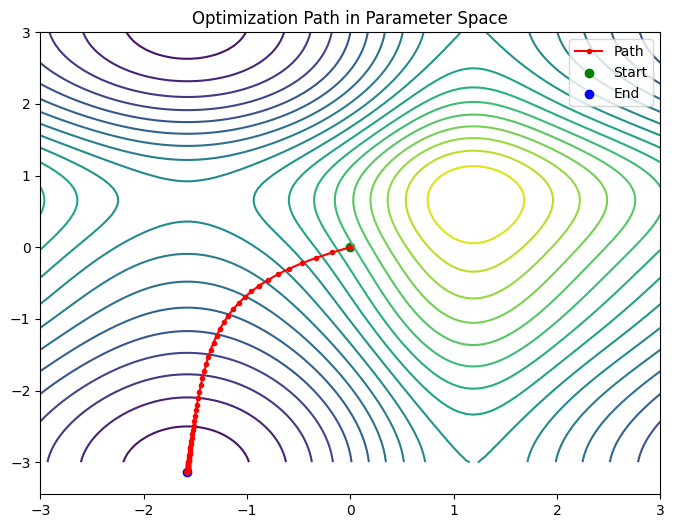

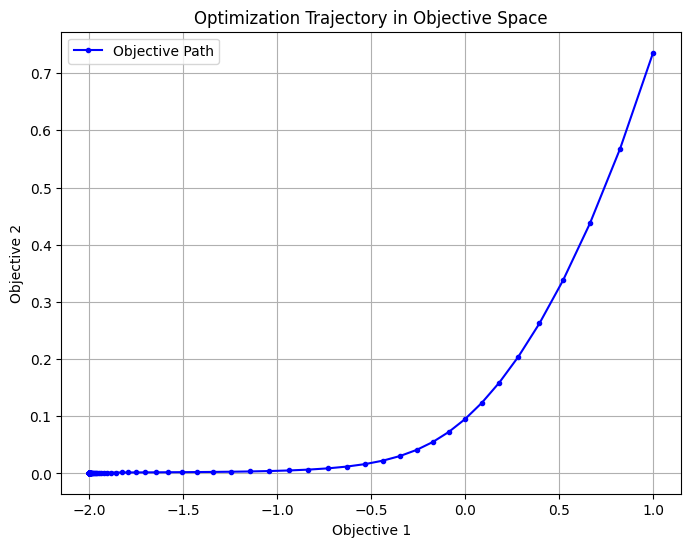

In [ ]:
# 3. Plot Optimization Path in Parameter Space
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z1 + Z2, levels=20)
plt.plot(history[:, 0], history[:, 1], '-ro', markersize=3, label='Path')
plt.scatter(history[0, 0], history[0, 1], color='green', label='Start')
plt.scatter(history[-1, 0], history[-1, 1], color='blue', label='End')
plt.title('Optimization Path in Parameter Space')
plt.legend()
plt.show()

# 4. Plot Objective Space
obj1_vals = [obj1.evaluate(p) for p in history]
obj2_vals = [obj2.evaluate(p) for p in history]

plt.figure(figsize=(8, 6))
plt.plot(obj1_vals, obj2_vals, 'b-o', markersize=3, label='Objective Path')
plt.xlabel('Objective 1')
plt.ylabel('Objective 2')
plt.title('Optimization Trajectory in Objective Space')
plt.grid(True)
plt.legend()
plt.show()